----
----
#  EXPLANATION NOTEBOOK:   

In this notebook we will Detail the workflow of our algorithm (main.py)
----
----
----

## IMPORT


In [1]:
from src.model_initialization import load_yolo_model, load_posenet_model, load_depth_estimation_model
from src.calibration import process_and_plot_calibration
from src.depth_estimation import estimate_depth
from src.direction_speed import calculate_direction, calculate_speed
from src.cost_map import create_time_dependent_cost_map, animate_cost_map, plot_all_time_dependent_cost_maps
from src.draw_boxes import detect_persons
from src.navigation_algo import probabilistic_astar, display_path
from src.utils import preprocess_boxes, calculate_pixel_value, horizontal_pixel_pos, horizontal_pos_conversion, predict_distance, get_image_size, resize_to_x_by_x

ImportError: cannot import name 'create_cost_map' from 'src.cost_map' (/Users/paulrichard/Documents/HAAN/src/cost_map.py)

----
----
## Models initialisation: 


In [ ]:
yolo_model = load_yolo_model()
posenet_model = load_posenet_model()
depth_processor, depth_model = load_depth_estimation_model()

Using cache found in /Users/paulrichard/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-8-13 Python-3.8.18 torch-2.0.1 CPU

Fusing layers... 
YOLOv5n summary: 213 layers, 1867405 parameters, 0 gradients
Adding AutoShape... 


YOLOv5 model loaded successfully.
MoveNet (PoseNet) model loaded successfully.
Depth estimation model loaded successfully.



----
----
## Calibration:

Here is the method we used to find best fitting curve

In [ ]:
%matplotlib inline

input_folder = '/Users/prichard/miniconda3/envs/infosys/cv_project/data/input/calibration/normal_size'
output_folder = '/Users/prichard/miniconda3/envs/infosys/cv_project/data/output'
#best_model, prediction_param = process_and_plot_calibration(input_folder, yolo_model, depth_processor, depth_model, output_folder)
best_model = "Polynomial"
prediction_param = (0.00029224, -0.10041, 8.3828)

Small image error = 0.2629 \
Medium image error = 0.2126 \
High image error = 0.2082 \
Normal image error = 0.1980


![Curve Data](images/Curve_Data_Big1_512.png)
![Curve Data](images/Curve_Data_Big1_1024.png)
![Curve Data](images/Curve_Data_Big1_2048.png)
![Curve Data](images/Curve_Data_Big1_3000.png)


Person detection complete. Found 2 persons.
Direction estimation complete


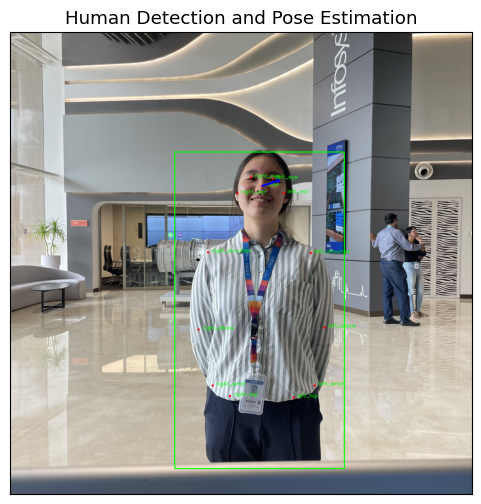

dynamic obstacle [((398, 686), 2.837743000178903, 1)]


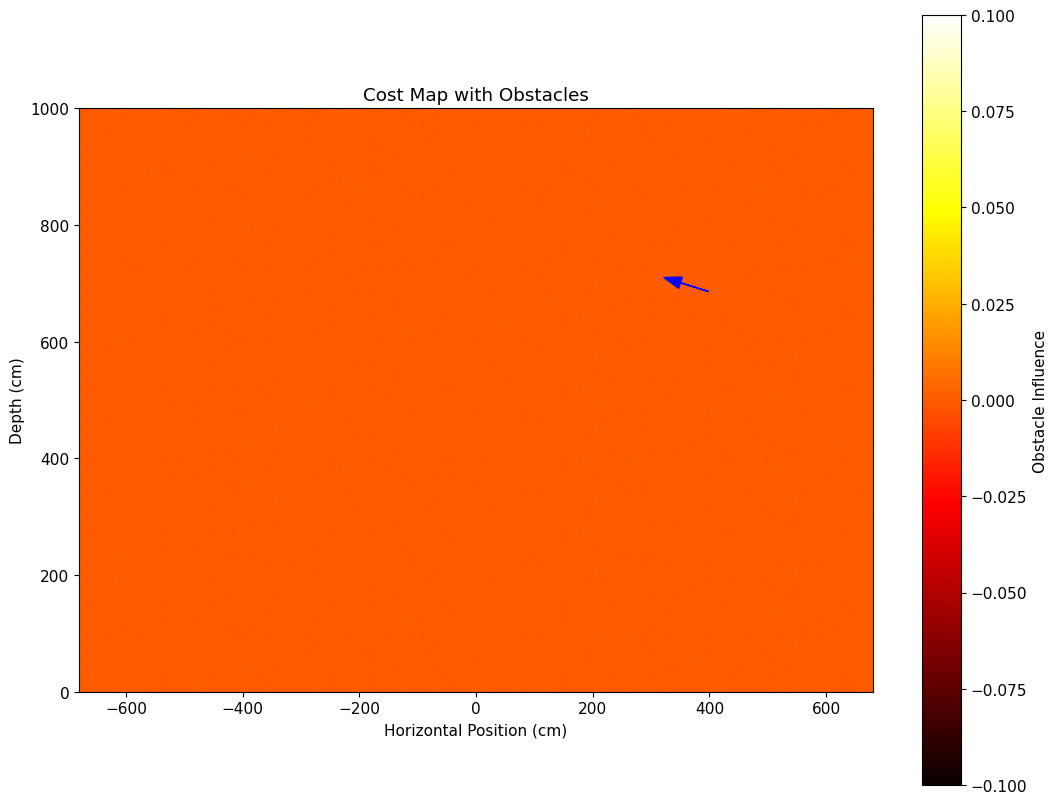

In [ ]:
test_image_path = "data/input/calibration/high_size/0.9.jpeg"
DISP = True

robot_speed = 1.11 #  [m/s]

new_size = (1280, 1280)

img, size_img = get_image_size(test_image_path)

resized_image = resize_to_x_by_x(img, new_size)

depth_image = estimate_depth(resized_image, depth_processor, depth_model) # 0.5
coords_box_in_pixel = detect_persons(resized_image, yolo_model) # traduire dans la nouvelle map et pour l'instant mettre tout en cm avec juste pixel = 0.1 cm

filtered_depth_images = preprocess_boxes(depth_image, coords_box_in_pixel)
pixel_values = calculate_pixel_value(filtered_depth_images)

horizontal_pos_in_pixel = horizontal_pixel_pos(coords_box_in_pixel)
horizontal_pos_in_cm = horizontal_pos_conversion(horizontal_pos_in_pixel) # here we change the coordinates st the 0,0 is the robot position 

depth_values = [predict_distance(pv, prediction_param, best_model.lower()) for pv in pixel_values]

directions = calculate_direction(resized_image, coords_box_in_pixel, depth_values, posenet_model, DISP)
speeds = calculate_speed(resized_image, coords_box_in_pixel)

prob_grid, dynamic_obstacles = create_cost_map(depth_values, horizontal_pos_in_cm, directions, speeds, robot_speed)
plot_cost_map(prob_grid, dynamic_obstacles)

In [ ]:
cost_map, dynamic_obstacles = create_time_dependent_cost_map(depth_values, horizontal_pos_in_cm, directions, speeds, time_steps=100, dt=10)

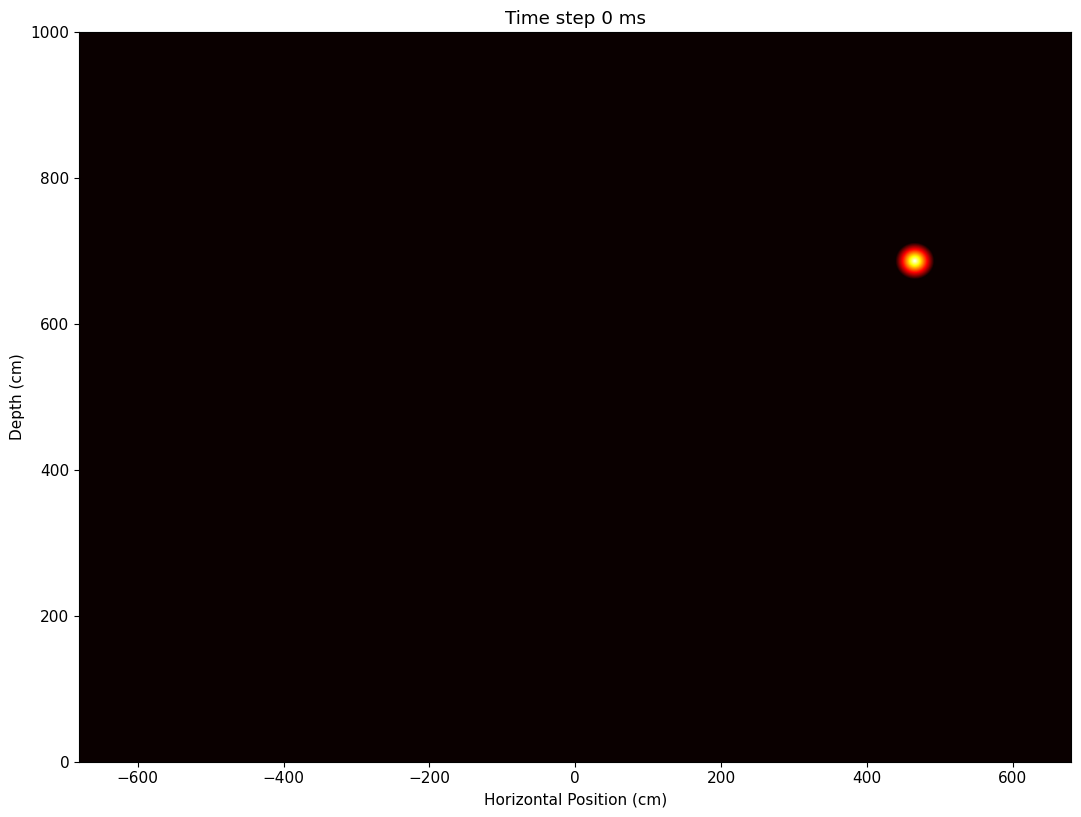

In [ ]:
from IPython.display import HTML 
# To display the animation in a Jupyter notebook:
anim = animate_cost_map(cost_map, dynamic_obstacles, time_steps=100, dt=10, interval=100)
HTML(anim.to_jshtml())

In [ ]:
print(prob_grid)
print(dynamic_obstacles)
print(prob_grid.shape)
print(prob_grid[728][188])

[[          0           0           0 ...           0           0           0]
 [          0           0           0 ...           0           0           0]
 [          0           0           0 ...           0           0           0]
 ...
 [          0           0           0 ...           0           0           0]
 [          0           0           0 ...           0           0           0]
 [          0           0           0 ...           0           0           0]]
[(array([[       1078,         686],
       [       1068,         688],
       [       1058,         691],
       [       1049,         694],
       [       1039,         697],
       [       1030,         700],
       [       1020,         703],
       [       1011,         706],
       [       1001,         709],
       [        992,         712],
       [        982,         715],
       [        973,         718],
       [        963,         721],
       [        953,         724],
       [        944,        

Path found: [(64, 0), (63, 0), (62, 0), (61, 0), (60, 0), (59, 0), (58, 0), (57, 0), (56, 0), (55, 0), (54, 0), (53, 0), (52, 0), (51, 0), (50, 0), (49, 0), (48, 0), (47, 0), (46, 0), (45, 0), (44, 0), (43, 0), (43, 1), (42, 1), (42, 2), (41, 2), (41, 3), (40, 3), (40, 4), (39, 4), (39, 5), (38, 5), (38, 6), (37, 6), (37, 7), (36, 7), (36, 8), (35, 8), (35, 9), (34, 9), (34, 10), (33, 10), (33, 11), (32, 11), (32, 12), (31, 12), (31, 13), (30, 13), (30, 14), (29, 14), (29, 15), (28, 15), (28, 16), (27, 16), (27, 17), (26, 17), (26, 18), (25, 18), (25, 19), (24, 19), (24, 20)]


ValueError: not enough values to unpack (expected 4, got 3)

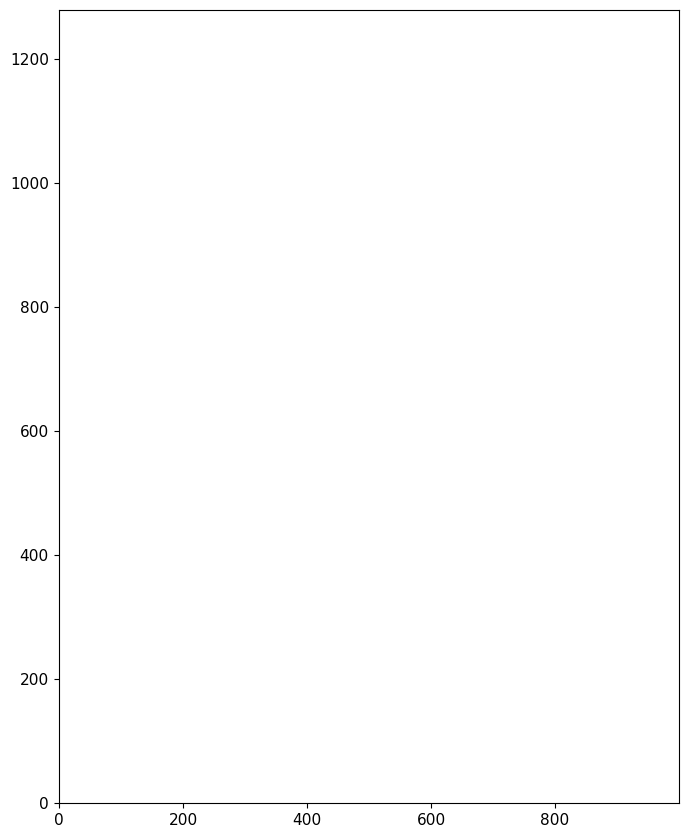

In [ ]:
start = (64, 0)
goal = (24, 20)
path = probabilistic_astar(prob_grid, prob_grid, start, goal)

if path:
    print("Path found:", path)
else:
    print("No path found")

display_path(prob_grid, path, prob_grid, dynamic_obstacles, start, goal)
Video

A Faire Demain: Prendre les nouvelles image avec le truc à 1 m \
recomparer les erreurs\
faire une matrice pour representer la map \
mettre en proba et essayer de plot 
